In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zarinsaimaroza/coin-dataset/Final_Balanced_Coin_Dataset/valid/2/5f_520.jpg
/kaggle/input/datasets/zarinsaimaroza/coin-dataset/Final_Balanced_Coin_Dataset/valid/2/5f_new168.jpg
/kaggle/input/datasets/zarinsaimaroza/coin-dataset/Final_Balanced_Coin_Dataset/valid/2/5f_1377.jpg
/kaggle/input/datasets/zarinsaimaroza/coin-dataset/Final_Balanced_Coin_Dataset/valid/2/5f_new445.jpg
/kaggle/input/datasets/zarinsaimaroza/coin-dataset/Final_Balanced_Coin_Dataset/valid/2/5f_754.jpg
/kaggle/input/datasets/zarinsaimaroza/coin-dataset/Final_Balanced_Coin_Dataset/valid/2/5f_new376.jpg
/kaggle/input/datasets/zarinsaimaroza/coin-dataset/Final_Balanced_Coin_Dataset/valid/2/5f_1389.jpg
/kaggle/input/datasets/zarinsaimaroza/coin-dataset/Final_Balanced_Coin_Dataset/valid/2/5f_1630.jpg
/kaggle/input/datasets/zarinsaimaroza/coin-dataset/Final_Balanced_Coin_Dataset/valid/2/5f_480.jpg
/kaggle/input/datasets/zarinsaimaroza/coin-dataset/Final_Balanced_Coin_Dataset/valid/2/5f_610.jpg
/kaggle/

In [2]:
!pip install timm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

In [3]:
!pip install timm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

In [4]:
dataset_path = "/kaggle/input/datasets/zarinsaimaroza/coin-dataset/Final_Balanced_Coin_Dataset/"

train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "valid")
test_dir = os.path.join(dataset_path, "test")

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [6]:
import os
import shutil
from torchvision import datasets
from torch.utils.data import DataLoader

# Original (read-only)
input_path = "/kaggle/input/datasets/zarinsaimaroza/coin-dataset/Final_Balanced_Coin_Dataset/"

# Writable path
working_path = "/kaggle/working/coin_dataset"

# Copy dataset (only once)
if not os.path.exists(working_path):
    shutil.copytree(input_path, working_path)

# New paths (IMPORTANT: use working path)
train_dir = os.path.join(working_path, "train")
val_dir = os.path.join(working_path, "valid")
test_dir = os.path.join(working_path, "test")

# Mapping
label_map = {
    "1f": "0",
    "2f": "1",
    "5f": "2",
    "1b": "3",
    "2b": "4",
    "5b": "5"
}

def move_unlabeled_images(base_dir):
    unlabeled_path = os.path.join(base_dir, "unlabeled")

    if not os.path.exists(unlabeled_path):
        return

    moved_count = 0

    for img_name in os.listdir(unlabeled_path):
        prefix = img_name.split("_")[0]

        if prefix in label_map:
            target_class = label_map[prefix]
            target_dir = os.path.join(base_dir, target_class)

            os.makedirs(target_dir, exist_ok=True)

            src_path = os.path.join(unlabeled_path, img_name)
            dst_path = os.path.join(target_dir, img_name)

            shutil.move(src_path, dst_path)
            moved_count += 1

    print(f"{base_dir} → moved {moved_count} images")

    # Remove folder if empty
    if len(os.listdir(unlabeled_path)) == 0:
        os.rmdir(unlabeled_path)


# Apply to all splits
for split_dir in [train_dir, val_dir, test_dir]:
    move_unlabeled_images(split_dir)

print("✅ Unlabeled images moved successfully!")

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Counts
print(f"Train images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images: {len(test_dataset)}")

/kaggle/working/coin_dataset/train → moved 1096 images
/kaggle/working/coin_dataset/valid → moved 161 images
/kaggle/working/coin_dataset/test → moved 305 images
✅ Unlabeled images moved successfully!
Train images: 6221
Validation images: 897
Test images: 1788


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model(
    "tf_efficientnetv2_b3",
    pretrained=True,
    num_classes=6
)

# Add custom dropout before classifier
in_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),   # 🔥 Added dropout
    nn.Linear(in_features, 6)
)

model = model.to(device)

model.safetensors:   0%|          | 0.00/57.9M [00:00<?, ?B/s]

In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    # verbose=True
)

In [9]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss

        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [10]:
early_stopping = EarlyStopping(patience=15)

In [11]:
EPOCHS = 100

train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_loss = float('inf')

for epoch in range(EPOCHS):

    # 🔹 TRAINING
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total


    # 🔹 VALIDATION
    model.eval()
    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # 🔹 Scheduler Step
    scheduler.step(val_loss)

    # 🔹 Print current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr:.6f}")

    # 🔹 Save Best Model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_coin_model.pth")
        print("✅ Best model saved.")

    # 🔹 Early Stopping Check
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("🚨 Early stopping triggered!")
        break


Epoch [1/100]
Train Loss: 0.3145 | Train Acc: 89.49%
Val Loss: 0.0315 | Val Acc: 99.00%
Current Learning Rate: 0.001000
✅ Best model saved.

Epoch [2/100]
Train Loss: 0.0994 | Train Acc: 96.77%
Val Loss: 0.0614 | Val Acc: 98.44%
Current Learning Rate: 0.001000

Epoch [3/100]
Train Loss: 0.0670 | Train Acc: 98.04%
Val Loss: 0.1228 | Val Acc: 95.65%
Current Learning Rate: 0.001000

Epoch [4/100]
Train Loss: 0.0880 | Train Acc: 97.44%
Val Loss: 0.0172 | Val Acc: 99.55%
Current Learning Rate: 0.001000
✅ Best model saved.

Epoch [5/100]
Train Loss: 0.0376 | Train Acc: 98.97%
Val Loss: 0.0279 | Val Acc: 98.77%
Current Learning Rate: 0.001000

Epoch [6/100]
Train Loss: 0.0660 | Train Acc: 98.01%
Val Loss: 0.1445 | Val Acc: 95.76%
Current Learning Rate: 0.001000

Epoch [7/100]
Train Loss: 0.0555 | Train Acc: 98.47%
Val Loss: 0.1403 | Val Acc: 97.88%
Current Learning Rate: 0.001000

Epoch [8/100]
Train Loss: 0.0603 | Train Acc: 98.07%
Val Loss: 0.0145 | Val Acc: 99.44%
Current Learning Rate: 0

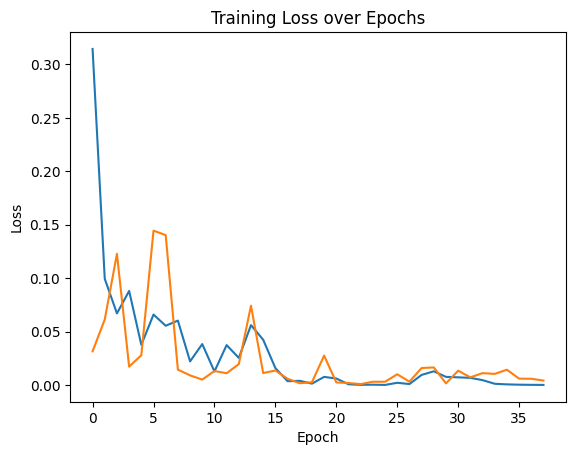

In [12]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# plt.figure()
# plt.plot(train_accs, label="Train Accuracy")
# plt.plot(val_accs, label="Validation Accuracy")
# plt.title("Accuracy over Epochs")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.legend()
# plt.show()

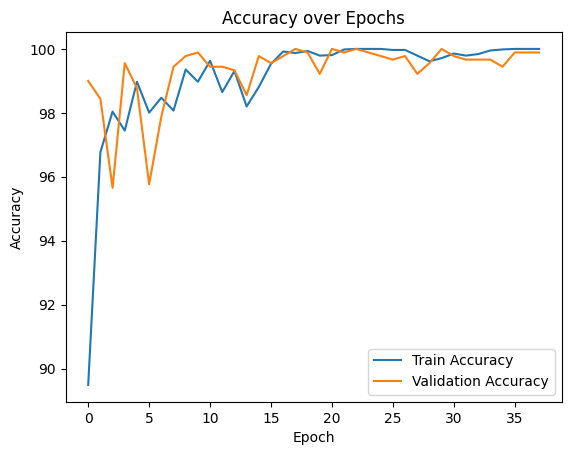

In [13]:
plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [14]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100 * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 99.89%


In [15]:
model.load_state_dict(torch.load("best_coin_model.pth"))
model.eval()

EfficientNet(
  (conv_stem): Conv2dSame(3, 40, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    40, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): ConvBnAct(
        (conv): Conv2d(40, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Identity()
      )
      (1): ConvBnAct(
        (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (drop_path):

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Get class names from the dataset, ensuring 'unlabeled' is excluded
# Assuming train_dataset.dataset.class_to_idx contains all original mappings
# and y_true contains labels from 0 to num_actual_classes - 1.
if isinstance(train_dataset, torch.utils.data.Subset):
    original_class_to_idx = train_dataset.dataset.class_to_idx
else:
    original_class_to_idx = train_dataset.class_to_idx

# Filter out the 'unlabeled' class from the mapping and create an index-to-class map
filtered_idx_to_class = {idx: cls for cls, idx in original_class_to_idx.items() if cls != 'unlabeled'}

# Determine the number of actual classes from the unique labels in y_true
num_actual_classes = len(np.unique(y_true))

# Create a sorted list of class names based on their integer labels
class_names = [filtered_idx_to_class[i] for i in range(num_actual_classes)]

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       336
           1       1.00      1.00      1.00       322
           2       1.00      1.00      1.00       543
           3       0.99      1.00      0.99       188
           4       1.00      1.00      1.00       183
           5       1.00      1.00      1.00       216

    accuracy                           1.00      1788
   macro avg       1.00      1.00      1.00      1788
weighted avg       1.00      1.00      1.00      1788



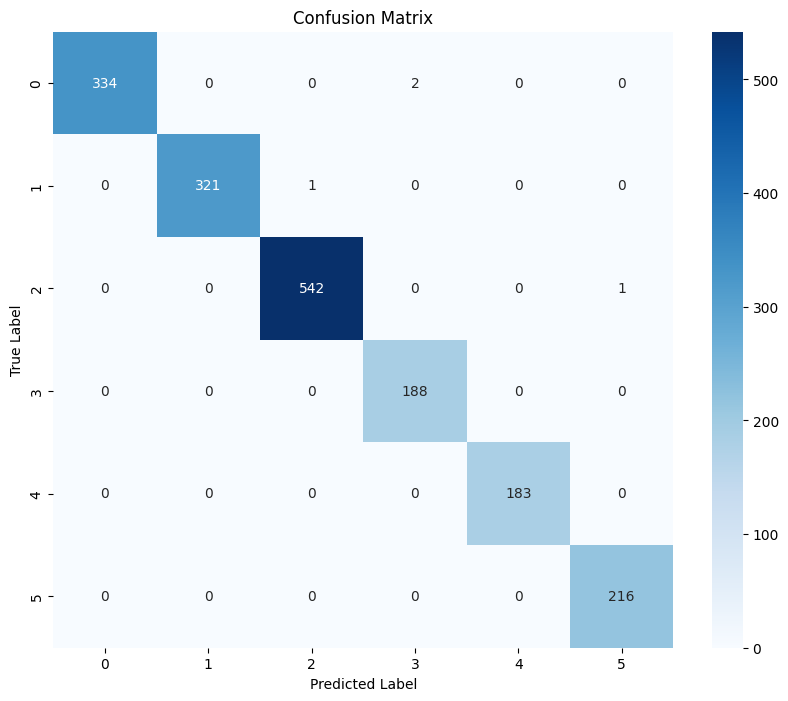

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

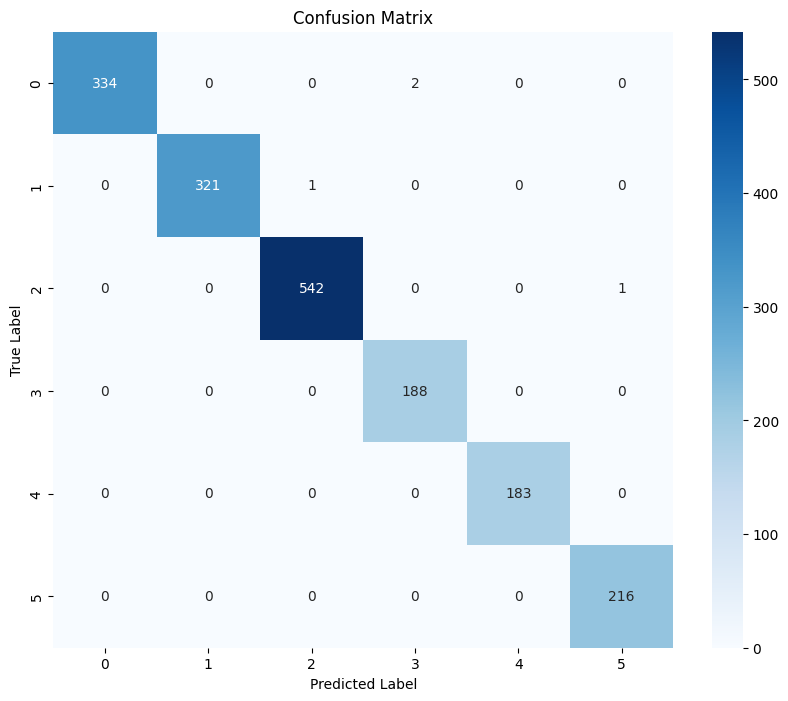

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()